## K-Nearest Neighbors — Diagnosing Fraudulent Insurance Claims
 
### Business Problem
 
An insurance company's claims operations team wants to flag potentially fraudulent claims for manual review before payout. Given claim-level features (claim amount, claimant history, type of incident), the model should classify each claim as likely legitimate or suspicious.
 
### Why K-Nearest Neighbors?
 
KNN is effective when the **decision boundary is locally complex but globally non-linear** — fraud patterns often cluster in feature space (e.g., a specific combination of high claim amounts, short policy tenure, and a particular incident type). KNN makes no parametric assumptions about the data distribution, which is valuable when fraud tactics evolve and the underlying patterns shift. It is also intuitive to explain to claims adjusters: "this claim resembles the N most similar past claims that were confirmed fraud." Caveat: KNN scales poorly with dataset size; for very large claim volumes, a tree-based ensemble would be preferred.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay

=== K-Nearest Neighbors: Fraud Detection ===
Best params: {'knn__n_neighbors': 15, 'knn__weights': 'distance'}
ROC-AUC:     0.8110

Classification Report Summary:
- Precision: The proportion of predicted churned customers that were actually churned. A high precision means that when the model predicts a customer will churn, it is usually correct.
- Recall: The proportion of actual churned customers that were correctly identified by the model. A high recall means that the model is good at finding most of the churned customers.
- F1-score: The harmonic mean of precision and recall. It provides a single metric that balances both precision and recall, especially useful when there is an imbalance in the classes.
- Support: The number of actual occurrences of each class in the test set. This helps to understand how many samples were evaluated for each class.

              precision    recall  f1-score   support

  Legitimate       0.79      0.93      0.85       117
       Fraud       0.64   

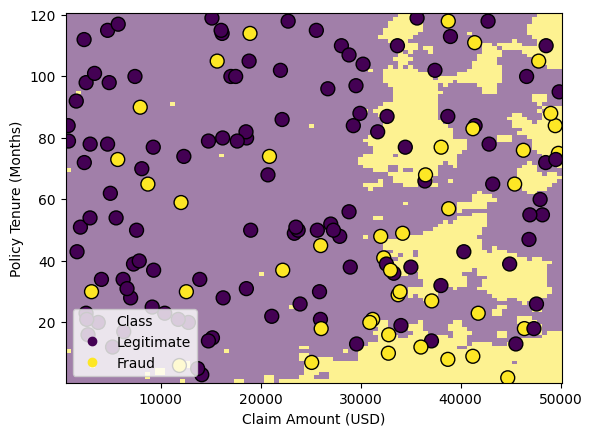

In [19]:
"""
Insurance fraud detection using K-Nearest Neighbors.
 
Business goal: Flag suspicious insurance claims for manual review
before processing payouts, reducing fraudulent disbursements.
"""


def generate_claims_data(n_samples: int = 800, seed: int = 42) -> pd.DataFrame:
    """Generate synthetic insurance claims dataset.

    Args:
        n_samples: Number of claims to simulate.
        seed: Random seed for reproducibility.

    Returns:
        DataFrame with claim features and fraud label.
    """
    rng = np.random.default_rng(seed)

    claim_amount = rng.uniform(500, 50_000, n_samples)
    policy_tenure_months = rng.integers(1, 120, n_samples)
    prior_claims = rng.integers(0, 5, n_samples)
    injury_severity = rng.integers(1, 5, n_samples)

    fraud_score = (
        (claim_amount > 30_000).astype(int) * 2
        + (policy_tenure_months < 12).astype(int) * 2
        + (prior_claims >= 3).astype(int) * 1
    )
    prob_fraud = np.clip(fraud_score / 5 + rng.uniform(-0.1, 0.1, n_samples), 0, 1)
    is_fraud = rng.binomial(1, prob_fraud)

    return pd.DataFrame(
        {
            "claim_amount_usd": claim_amount,
            "policy_tenure_months": policy_tenure_months,
            "prior_claims": prior_claims,
            "injury_severity": injury_severity,
            "is_fraud": is_fraud,
        }
    )


"""Train, tune, and evaluate fraud detection model."""
df = generate_claims_data()
feature_cols = [c for c in df.columns if c != "is_fraud"]

X = df[feature_cols]
y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier()),
    ]
)


param_grid = {
    "knn__n_neighbors": [3, 5, 7, 11, 15],
    "knn__weights": ["uniform", "distance"],
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring="roc_auc", n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)

print("=== K-Nearest Neighbors: Fraud Detection ===")
print(f"Best params: {grid_search.best_params_}")
print(f"ROC-AUC:     {auc:.4f}\n")
print("""Classification Report Summary:
- Precision: The proportion of predicted churned customers that were actually churned. A high precision means that when the model predicts a customer will churn, it is usually correct.
- Recall: The proportion of actual churned customers that were correctly identified by the model. A high recall means that the model is good at finding most of the churned customers.
- F1-score: The harmonic mean of precision and recall. It provides a single metric that balances both precision and recall, especially useful when there is an imbalance in the classes.
- Support: The number of actual occurrences of each class in the test set. This helps to understand how many samples were evaluated for each class.
""")
print(classification_report(y_test, y_pred, target_names=["Legitimate", "Fraud"]))

# Visialize decision boundaries (for 2 features)
X_test_2d = X_test[["claim_amount_usd", "policy_tenure_months"]]
best_model.fit(X_train[["claim_amount_usd", "policy_tenure_months"]], y_train)
disp = DecisionBoundaryDisplay.from_estimator(
    best_model,
    X_test_2d,
    response_method="predict",
    plot_method="pcolormesh",
    xlabel="Claim Amount (USD)",
    ylabel="Policy Tenure (Months)",
    shading="auto",
    alpha=0.5,
)
scatter = disp.ax_.scatter(
    X_test_2d["claim_amount_usd"],
    X_test_2d["policy_tenure_months"],
    c=y_test,
    edgecolor="k",
    s=100,
)
disp.ax_.legend(
    scatter.legend_elements()[0],
    ["Legitimate", "Fraud"],
    title="Class",
    loc="lower left",
)